# 1. Objectif

# Industrial Visual Change Detection

Prototype Python pour comparer deux images d'une même zone industrielle prises à deux instants différents, détecter des écarts visuels et produire une table de zones à vérifier.

On cherche à localiser les zones où l'image diffère entre deux dates. La sortie finale n'est pas une décision automatique : elle sert à préparer une revue manuelle des régions candidates. Le notebook utilise des images synthétiques afin de rester reproductible et d'éviter l'usage de données industrielles sensibles.

# 2. Imports et paramètres

Une image couleur peut être représentée comme un tenseur :

$$
I \in \mathbb{R}^{H \times W \times C}
$$

avec $H$ la hauteur, $W$ la largeur et $C$ le nombre de canaux. Dans ce notebook, les traitements de comparaison sont appliqués sur des images converties en niveaux de gris.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim

SEED = 42
IMAGE_HEIGHT = 720
IMAGE_WIDTH = 1080
MIN_REGION_AREA_PX = 900
MORPH_KERNEL_SIZE = 7

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)

# 3. Génération ou chargement des images

Les images sont synthétiques pour garantir la reproductibilité du notebook et éviter l'usage de données industrielles sensibles. L'image `before` représente l'état de référence. L'image `after_shifted` simule une prise de vue ultérieure avec quelques modifications visibles et un léger décalage de cadrage.

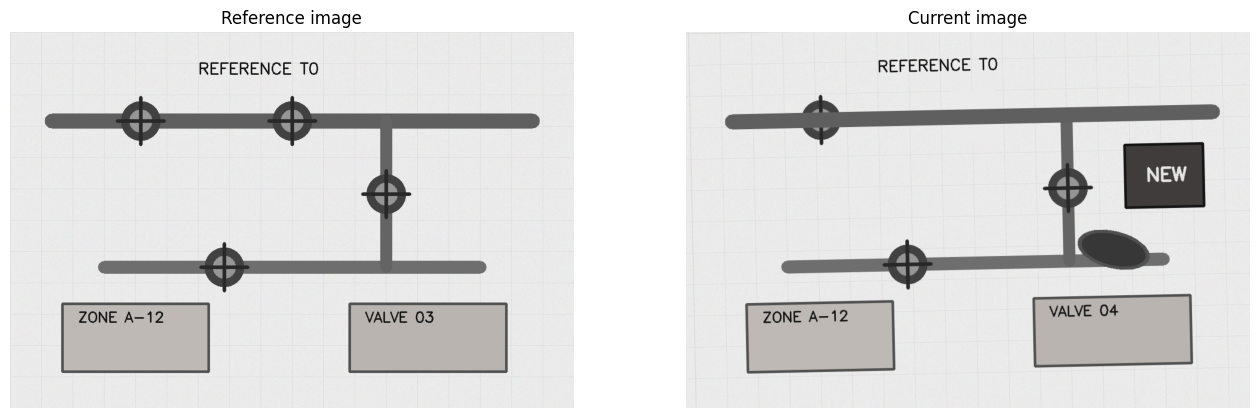

In [2]:
def create_synthetic_industrial_scene(seed=SEED):
    rng = np.random.default_rng(seed)
    img = np.full((IMAGE_HEIGHT, IMAGE_WIDTH, 3), 235, dtype=np.uint8)

    noise = rng.normal(0, 4, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    for x in range(0, IMAGE_WIDTH, 60):
        cv2.line(img, (x, 0), (x, IMAGE_HEIGHT), (220, 220, 220), 1)
    for y in range(0, IMAGE_HEIGHT, 60):
        cv2.line(img, (0, y), (IMAGE_WIDTH, y), (220, 220, 220), 1)

    cv2.line(img, (80, 170), (1000, 170), (95, 95, 95), 28)
    cv2.line(img, (180, 450), (900, 450), (110, 110, 110), 24)
    cv2.line(img, (720, 170), (720, 450), (100, 100, 100), 22)

    for center in [(250, 170), (540, 170), (720, 310), (410, 450)]:
        cv2.circle(img, center, 38, (65, 65, 65), -1)
        cv2.circle(img, center, 22, (150, 150, 150), -1)
        cv2.line(img, (center[0] - 45, center[1]), (center[0] + 45, center[1]), (40, 40, 40), 6)
        cv2.line(img, (center[0], center[1] - 45), (center[0], center[1] + 45), (40, 40, 40), 6)

    cv2.rectangle(img, (100, 520), (380, 650), (180, 185, 190), -1)
    cv2.rectangle(img, (100, 520), (380, 650), (80, 80, 80), 3)
    cv2.rectangle(img, (650, 520), (950, 650), (175, 180, 185), -1)
    cv2.rectangle(img, (650, 520), (950, 650), (80, 80, 80), 3)

    cv2.putText(img, "ZONE A-12", (130, 555), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (20, 20, 20), 2)
    cv2.putText(img, "VALVE 03", (680, 555), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (20, 20, 20), 2)
    cv2.putText(img, "REFERENCE T0", (360, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 2)
    return img


def create_changed_scene(reference_bgr):
    changed = reference_bgr.copy()

    cv2.rectangle(changed, (500, 120), (585, 220), (235, 235, 235), -1)
    cv2.line(changed, (80, 170), (1000, 170), (95, 95, 95), 28)

    cv2.ellipse(changed, (805, 430), (70, 35), 15, 0, 360, (80, 80, 80), -1)
    cv2.ellipse(changed, (805, 430), (62, 29), 15, 0, 360, (55, 55, 55), -1)

    cv2.rectangle(changed, (830, 230), (980, 350), (60, 60, 65), -1)
    cv2.rectangle(changed, (830, 230), (980, 350), (20, 20, 20), 3)
    cv2.putText(changed, "NEW", (870, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (230, 230, 230), 3)

    cv2.rectangle(changed, (680, 535), (850, 570), (175, 180, 185), -1)
    cv2.putText(changed, "VALVE 04", (680, 555), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (20, 20, 20), 2)
    return changed


before = create_synthetic_industrial_scene()
after = create_changed_scene(before)

transform = cv2.getRotationMatrix2D((IMAGE_WIDTH // 2, IMAGE_HEIGHT // 2), angle=1.2, scale=1.0)
transform[:, 2] += np.array([12, -8])
after_shifted = cv2.warpAffine(after, transform, (IMAGE_WIDTH, IMAGE_HEIGHT), borderMode=cv2.BORDER_REFLECT)

cv2.imwrite(str(OUTPUT_DIR / "before.png"), before)
cv2.imwrite(str(OUTPUT_DIR / "after_shifted.png"), after_shifted)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
axes[0].set_title("Reference image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(after_shifted, cv2.COLOR_BGR2RGB))
axes[1].set_title("Current image")
axes[1].axis("off")
plt.show()

# 4. Prétraitement

Cette étape réduit l'impact du bruit local avant la comparaison. Les images sont converties en niveaux de gris, puis un léger filtre gaussien est appliqué. Le redimensionnement n'est pas nécessaire ici car les deux images synthétiques ont les mêmes dimensions.

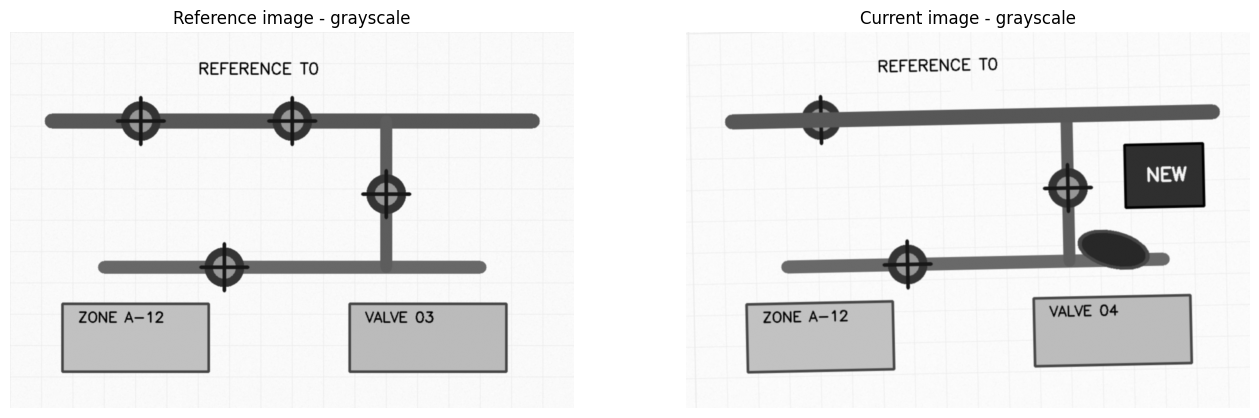

In [3]:
def preprocess_for_comparison(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (3, 3), 0)


before_gray = preprocess_for_comparison(before)
after_shifted_gray = preprocess_for_comparison(after_shifted)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(before_gray, cmap="gray")
axes[0].set_title("Reference image - grayscale")
axes[0].axis("off")
axes[1].imshow(after_shifted_gray, cmap="gray")
axes[1].set_title("Current image - grayscale")
axes[1].axis("off")
plt.show()

# 5. Alignement des images

Cette étape réduit l'impact des petits décalages entre les prises de vue. L'alignement utilisé ici repose sur l'optimisation ECC d'OpenCV avec une transformation affine. Cette approche convient à la simulation du notebook, mais elle ne couvre pas tous les cas réels : changements de perspective importants, occultations, variations fortes d'éclairage ou scènes peu texturées.

ECC correlation score: 0.7729
Transform matrix:
[[ 0.9997423   0.02091322  4.598225  ]
 [-0.02111507  0.99973446  3.4541132 ]]


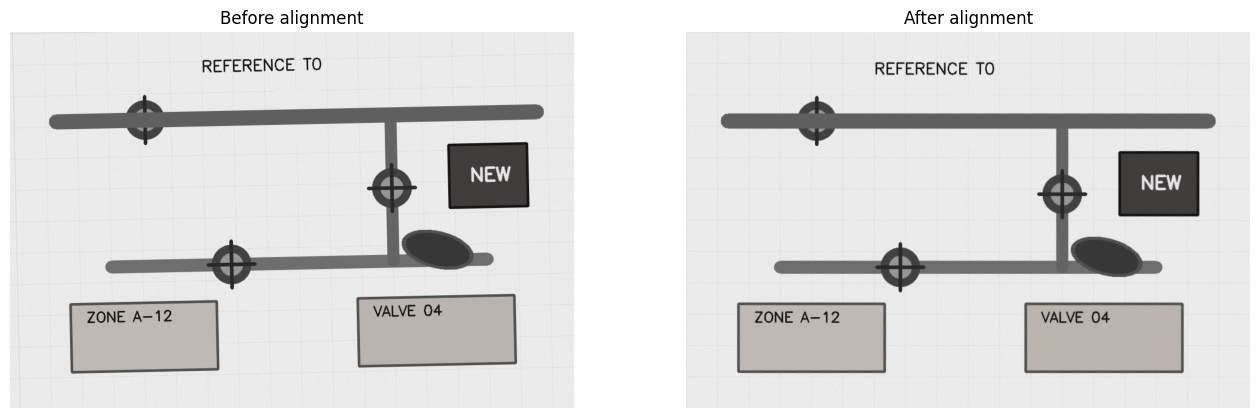

In [4]:
def align_image_ecc(reference_bgr, target_bgr, motion_model=cv2.MOTION_AFFINE, max_iterations=2000, eps=1e-7):
    ref_gray = preprocess_for_comparison(reference_bgr).astype(np.float32) / 255.0
    tgt_gray = preprocess_for_comparison(target_bgr).astype(np.float32) / 255.0

    warp_matrix = np.eye(3, 3, dtype=np.float32) if motion_model == cv2.MOTION_HOMOGRAPHY else np.eye(2, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, max_iterations, eps)

    try:
        correlation, warp_matrix = cv2.findTransformECC(ref_gray, tgt_gray, warp_matrix, motion_model, criteria)
    except cv2.error:
        return target_bgr.copy(), None, np.nan

    height, width = reference_bgr.shape[:2]
    if motion_model == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(
            target_bgr,
            warp_matrix,
            (width, height),
            flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_REFLECT,
        )
    else:
        aligned = cv2.warpAffine(
            target_bgr,
            warp_matrix,
            (width, height),
            flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_REFLECT,
        )
    return aligned, warp_matrix, correlation


after_aligned, warp_matrix, correlation = align_image_ecc(before, after_shifted)

print(f"ECC correlation score: {correlation:.4f}")
print("Transform matrix:")
print(warp_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(after_shifted, cv2.COLOR_BGR2RGB))
axes[0].set_title("Before alignment")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(after_aligned, cv2.COLOR_BGR2RGB))
axes[1].set_title("After alignment")
axes[1].axis("off")
plt.show()

# 6. Détection des différences

Une différence absolue pixel à pixel peut s'écrire :

$$
D(x,y) = |I_1(x,y) - I_2(x,y)|
$$

Le SSIM compare aussi la structure locale des deux images :

$$
SSIM(x,y)=
\frac{(2\mu_x\mu_y+C_1)(2\sigma_{xy}+C_2)}
{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}
$$

Une zone avec faible similarité structurelle est candidate à un changement. On utilise ici la carte inversée $1 - SSIM$ comme carte de différence.

Global SSIM for aligned T0/T1 images: 0.9555


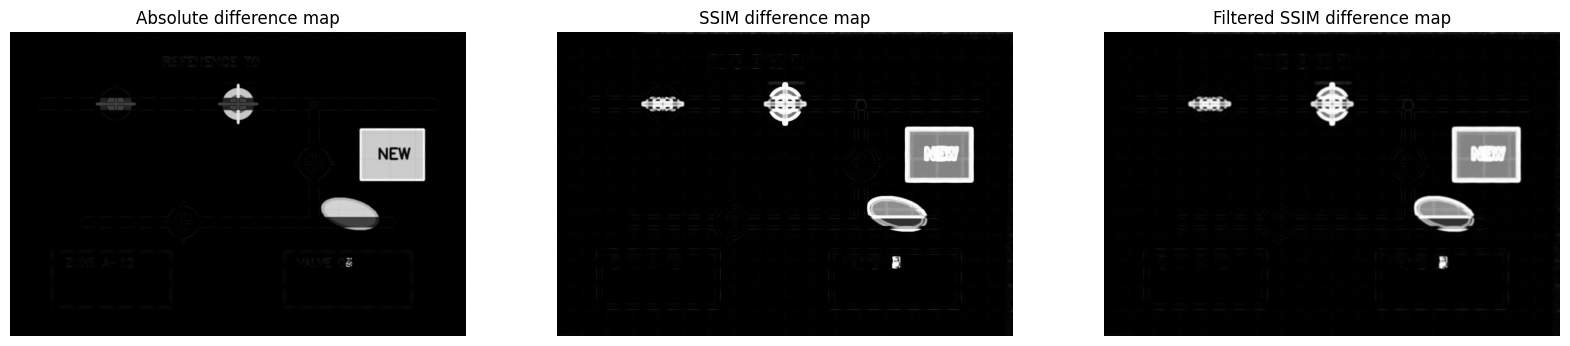

In [5]:
def compute_difference_maps(reference_bgr, aligned_bgr):
    ref_gray = preprocess_for_comparison(reference_bgr)
    aligned_gray = preprocess_for_comparison(aligned_bgr)

    abs_diff = cv2.absdiff(ref_gray, aligned_gray)
    ssim_score, ssim_map = ssim(ref_gray, aligned_gray, full=True, data_range=255)
    ssim_difference = ((1 - ssim_map) * 255).clip(0, 255).astype(np.uint8)
    ssim_difference_blur = cv2.GaussianBlur(ssim_difference, (5, 5), 0)
    return ssim_score, abs_diff, ssim_difference, ssim_difference_blur


ssim_score, abs_diff, ssim_difference, ssim_difference_blur = compute_difference_maps(before, after_aligned)
print(f"Global SSIM for aligned T0/T1 images: {ssim_score:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(abs_diff, cmap="gray")
axes[0].set_title("Absolute difference map")
axes[0].axis("off")
axes[1].imshow(ssim_difference, cmap="gray")
axes[1].set_title("SSIM difference map")
axes[1].axis("off")
axes[2].imshow(ssim_difference_blur, cmap="gray")
axes[2].set_title("Filtered SSIM difference map")
axes[2].axis("off")
plt.show()

# 7. Extraction des régions

Le seuillage transforme une carte de différence continue en masque binaire :

$$
M(x,y) = \mathbf{1}_{D(x,y) > \tau}
$$

Le seuil $\tau$ est estimé par la méthode d'Otsu. Les opérations morphologiques regroupent les pixels détectés et réduisent les petites zones isolées. Une région détectée peut être résumée par une bounding box :

$$
B = (x_{\min}, y_{\min}, x_{\max}, y_{\max})
$$

In [6]:
def extract_change_regions(difference_map, min_area=MIN_REGION_AREA_PX, kernel_size=MORPH_KERNEL_SIZE):
    _, threshold = cv2.threshold(difference_map, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(threshold, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.dilate(mask, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < min_area:
            continue

        x, y, width, height = cv2.boundingRect(contour)
        x_max = x + width
        y_max = y + height
        region_diff = difference_map[y:y_max, x:x_max]

        regions.append(
            {
                "x_min": int(x),
                "y_min": int(y),
                "x_max": int(x_max),
                "y_max": int(y_max),
                "area_px": int(area),
                "mean_difference": round(float(np.mean(region_diff)), 2),
            }
        )

    regions = sorted(regions, key=lambda row: row["area_px"], reverse=True)
    for idx, region in enumerate(regions, start=1):
        region["id_region"] = f"region_{idx:03d}"

    columns = ["id_region", "x_min", "y_min", "x_max", "y_max", "area_px", "mean_difference"]
    return mask, pd.DataFrame(regions, columns=columns)


change_mask, regions_df = extract_change_regions(ssim_difference_blur)
regions_df

,id_region,x_min,y_min,x_max,y_max,area_px,mean_difference
0,region_001,817,218,994,364,25290,154.84
1,region_002,728,382,881,479,11613,105.25
2,region_003,484,112,597,228,8447,98.74
3,region_004,194,149,307,192,3848,102.00
4,region_005,787,525,819,566,1148,83.25


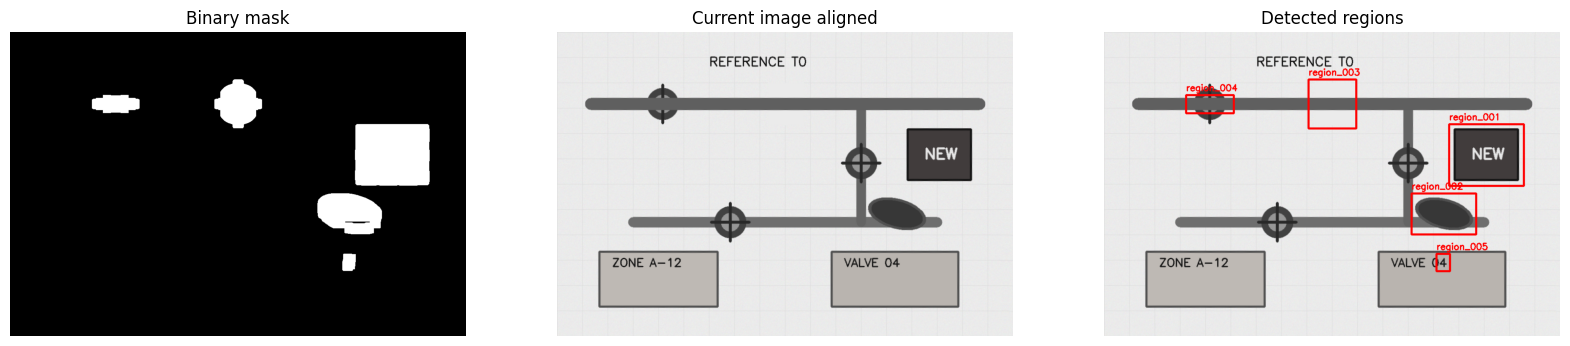

In [7]:
def draw_regions(image_bgr, regions_df):
    annotated = image_bgr.copy()
    for row in regions_df.itertuples(index=False):
        cv2.rectangle(annotated, (row.x_min, row.y_min), (row.x_max, row.y_max), (0, 0, 255), 3)
        cv2.putText(
            annotated,
            row.id_region,
            (row.x_min, max(row.y_min - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 0, 255),
            2,
        )
    return annotated


annotated = draw_regions(after_aligned, regions_df)
cv2.imwrite(str(OUTPUT_DIR / "after_annotated_changes.png"), annotated)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(change_mask, cmap="gray")
axes[0].set_title("Binary mask")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(after_aligned, cv2.COLOR_BGR2RGB))
axes[1].set_title("Current image aligned")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[2].set_title("Detected regions")
axes[2].axis("off")
plt.show()

# 8. Structuration des résultats

Un score de changement simple peut combiner la surface de la région et son intensité moyenne :

$$
S = \alpha \cdot \frac{A}{A_{\max}} + (1-\alpha) \cdot \bar{D}
$$

où :

- $A$ est l'aire de la région détectée ;
- $A_{\max}$ est l'aire maximale observée ;
- $\bar{D}$ est la différence moyenne normalisée dans la région ;
- $\alpha \in [0,1]$ pondère l'importance de l'aire.

Ce score sert uniquement à ordonner les régions candidates. Les champs `comment` et `review_status` préparent une vérification manuelle.

In [8]:
def assign_priority(change_score):
    if change_score >= 0.55:
        return "high"
    if change_score >= 0.25:
        return "medium"
    return "low"


def build_results_table(regions_df):
    results = regions_df.copy()
    if results.empty:
        results["priority"] = pd.Series(dtype="object")
        results["comment"] = pd.Series(dtype="object")
        results["review_status"] = pd.Series(dtype="object")
        return results

    alpha = 0.5
    max_area = max(results["area_px"].max(), 1)
    normalized_area = results["area_px"] / max_area
    normalized_difference = results["mean_difference"] / 255
    change_score = alpha * normalized_area + (1 - alpha) * normalized_difference

    results["priority"] = change_score.apply(assign_priority)
    results["comment"] = results.apply(
        lambda row: (
            f"Candidate region to review: bbox=({row.x_min}, {row.y_min}, {row.x_max}, {row.y_max}), "
            f"area_px={row.area_px}, mean_difference={row.mean_difference}."
        ),
        axis=1,
    )
    results["review_status"] = "pending"
    return results[
        [
            "id_region",
            "x_min",
            "y_min",
            "x_max",
            "y_max",
            "area_px",
            "mean_difference",
            "priority",
            "comment",
            "review_status",
        ]
    ]


results_df = build_results_table(regions_df)
results_df

,id_region,x_min,y_min,x_max,y_max,area_px,mean_difference,priority,comment,review_status
0,region_001,817,218,994,364,25290,154.84,high,"Candidate region to review: bbox=(817, 218, 99...",pending
1,region_002,728,382,881,479,11613,105.25,medium,"Candidate region to review: bbox=(728, 382, 88...",pending
2,region_003,484,112,597,228,8447,98.74,medium,"Candidate region to review: bbox=(484, 112, 59...",pending
3,region_004,194,149,307,192,3848,102.00,medium,"Candidate region to review: bbox=(194, 149, 30...",pending
4,region_005,787,525,819,566,1148,83.25,low,"Candidate region to review: bbox=(787, 525, 81...",pending


# 9. Export

La table est exportée en CSV pour pouvoir être relue ou intégrée dans un outil de suivi. Le fichier contient les coordonnées des régions, des métriques simples et un statut de revue.

In [9]:
export_path = OUTPUT_DIR / "detected_visual_changes.csv"
results_df.to_csv(export_path, index=False, encoding="utf-8")

print(f"CSV exported: {export_path}")
print(f"Detected regions: {len(results_df)}")

CSV exported: outputs\detected_visual_changes.csv
Detected regions: 5


# 10. Limites et pistes d'amélioration

Cette méthode est un prototype reproductible de détection d'écarts visuels. Elle reste sensible à l'éclairage, au cadrage et aux changements de perspective. Des faux positifs sont possibles, notamment sur les ombres, reflets, textures répétitives ou zones mal alignées.

Une évaluation fiable nécessiterait un jeu de données annoté avec des exemples représentatifs. Selon le besoin, la suite peut inclure un modèle de segmentation, un détecteur d'objets ou une méthode d'anomaly detection, avec validation sur données réelles.